# Fixed-camera X-cut and Z-sweep

The camera, XYZ limits, and canvas remain fixed while the retained Z range changes. The reference mask uses the magenta WT, red TC, and yellow ET palette. A decreasing Z boundary removes high-index layers; anatomical superior/inferior orientation still depends on the NIfTI affine.

In [ ]:
from pathlib import Path
import os
import sys
from functools import partial

_start = Path(os.environ.get("BRATS_PROJECT_ROOT", Path.cwd())).expanduser().resolve()
PROJECT_ROOT = next(
    (p for p in (_start, *_start.parents) if (p / "src" / "brats_pipeline").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Place notebooks/ and src/ under one project root, or set BRATS_PROJECT_ROOT.")
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))
os.chdir(PROJECT_ROOT)
from brats_pipeline.common import ProjectPaths
paths_io = ProjectPaths(PROJECT_ROOT)
resolve_existing_path = paths_io.resolve
print("Project:", PROJECT_ROOT)

In [2]:
import json
from dataclasses import asdict
import numpy as np
import pandas as pd
from IPython.display import Image, Video, display
from brats_pipeline.common import array_digest, signature, save_json
from brats_pipeline.data import load_nii, jp, canonicalize_brats_labels, validate_label_values
from brats_pipeline.rendering import (
    BrainManualCut3D, SweepStyle, precompute_xcut_volume, save_z_frame,
    render_z_sweep, order_z_frames, frames_to_mp4,
)

/home/mandrakedrink/miniforge3/envs/research_dt_bs/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Case and sweep configuration

In [3]:
PATIENT_ID = "BraTS2021_00142"
MANIFEST_PATH = PROJECT_ROOT / "data/processed/manifest_4clients_seed42.csv"
OUTPUT_ROOT = PROJECT_ROOT / "docs/figures/brats_3d_z_sweep_red_magenta_yellow3"

X_STOP = 150
Y_STOP = 240
PREVIEW_Z = 120
Z_STEP = 2
SWEEP_DIRECTION = "top_to_bottom"
FPS = 12
FORCE_RENDER = False
RENDER_VIDEO = False
HOLD_START_FRAMES = 0
HOLD_END_FRAMES = 0

REGION_COLORS = {
    "WT": (1.0, 0.0, 0.8, 1.0),
    "TC": (1.0, 0.05, 0.05, 1.0),
    "ET": (1.0, 1.0, 0.0, 1.0),
}
STYLE = SweepStyle(
    title="BraTS | GT Regions | X-Cut Z-Sweep",
    angle=35, elev=25, dpi=140,
    axes_rect=(0.00, 0.16, 1.00, 0.875), volume_zoom=1.50,
    legend_anchor=(0.035, 0.028), legend_fontsize=12,
    canvas_figsize=(9.0, 9.0), title_y=0.975, title_fontsize=28,
)

## Resolve one MRI case

In [4]:
def resolve_case(patient_id):
    if MANIFEST_PATH.exists():
        manifest = pd.read_csv(MANIFEST_PATH)
        rows = manifest[manifest["patient_id"].astype(str) == str(patient_id)]
        if len(rows) > 1:
            raise ValueError(f"Duplicate manifest entries for {patient_id}.")
        if len(rows) == 1:
            row = rows.iloc[0]
            mapping = jp(row["paths"])
            resolved = {key: paths_io.resolve(mapping[key], required=False)
                        for key in ("t1", "t1ce", "t2", "flair", "seg")}
            if all(path is not None for path in resolved.values()):
                return resolved, {"patient_id": patient_id, "client_domain": row["client_domain"],
                                  "split": row["split"], "source": "manifest"}
    raw_root = PROJECT_ROOT / "data/raw/brats2021"
    matches = sorted(raw_root.glob(f"**/{patient_id}/{patient_id}_flair.nii.gz"))
    if len(matches) != 1:
        raise FileNotFoundError(f"Expected one raw case directory, found {len(matches)} for {patient_id}.")
    directory = matches[0].parent
    mapping = {name: directory / f"{patient_id}_{name}.nii.gz"
               for name in ("t1", "t1ce", "t2", "flair", "seg")}
    if not all(path.is_file() for path in mapping.values()):
        raise FileNotFoundError(f"Incomplete case directory: {directory}")
    return mapping, {"patient_id": patient_id, "client_domain": directory.parent.name,
                     "split": directory.parent.parent.name, "source": "raw_directory"}

case_paths, case_meta = resolve_case(PATIENT_ID)
flair = load_nii(case_paths["flair"])
raw_seg = load_nii(case_paths["seg"])
validate_label_values(raw_seg)
seg = canonicalize_brats_labels(raw_seg)
if flair.shape != seg.shape:
    raise ValueError("MRI and ground-truth shape mismatch.")

viz_z = BrainManualCut3D.for_video(
    resize_volume=False, crop_bg=False, cmap_name="gray", figsize=(9.0, 9.0),
    title_fontsize=30, legend_fontsize=12, title_pad=8,
    subplot_adjust=(0.00, 1.00, 0.00, 1.00), cmap_range=(0.06, 0.78),
    region_colors=REGION_COLORS,
)
run_settings = {"case": case_meta, "image": array_digest(flair), "labels": array_digest(seg),
                "x_stop": X_STOP, "y_stop": Y_STOP, "z_step": Z_STEP,
                "direction": SWEEP_DIRECTION, "palette": REGION_COLORS, "style": asdict(STYLE)}
CASE_OUTPUT_ROOT = OUTPUT_ROOT / f"{PATIENT_ID}__{signature(run_settings)[:12]}"
PREVIEW_DIR = CASE_OUTPUT_ROOT / "previews"
FRAMES_DIR = CASE_OUTPUT_ROOT / "frames"
VIDEO_DIR = CASE_OUTPUT_ROOT / "videos"
for directory in (PREVIEW_DIR, FRAMES_DIR, VIDEO_DIR):
    directory.mkdir(parents=True, exist_ok=True)
save_json(run_settings, CASE_OUTPUT_ROOT / "run_settings.json")
print(case_meta)
print("MRI shape:", flair.shape, "labels:", np.unique(seg))
print("Output:", CASE_OUTPUT_ROOT)

{'patient_id': 'BraTS2021_00142', 'client_domain': 'TCGA-GBM', 'split': 'train', 'source': 'manifest'}
MRI shape: (240, 240, 155) labels: [0 1 2 3]
Output: /home/mandrakedrink/projects/research_ts_bs/docs/figures/brats_3d_z_sweep_red_magenta_yellow3/BraTS2021_00142__87e4297250af


## Inspect one frame

brain_full: (240, 240, 155)
brain_base: (150, 240, 155)
seg labels: [0 1 2 3]


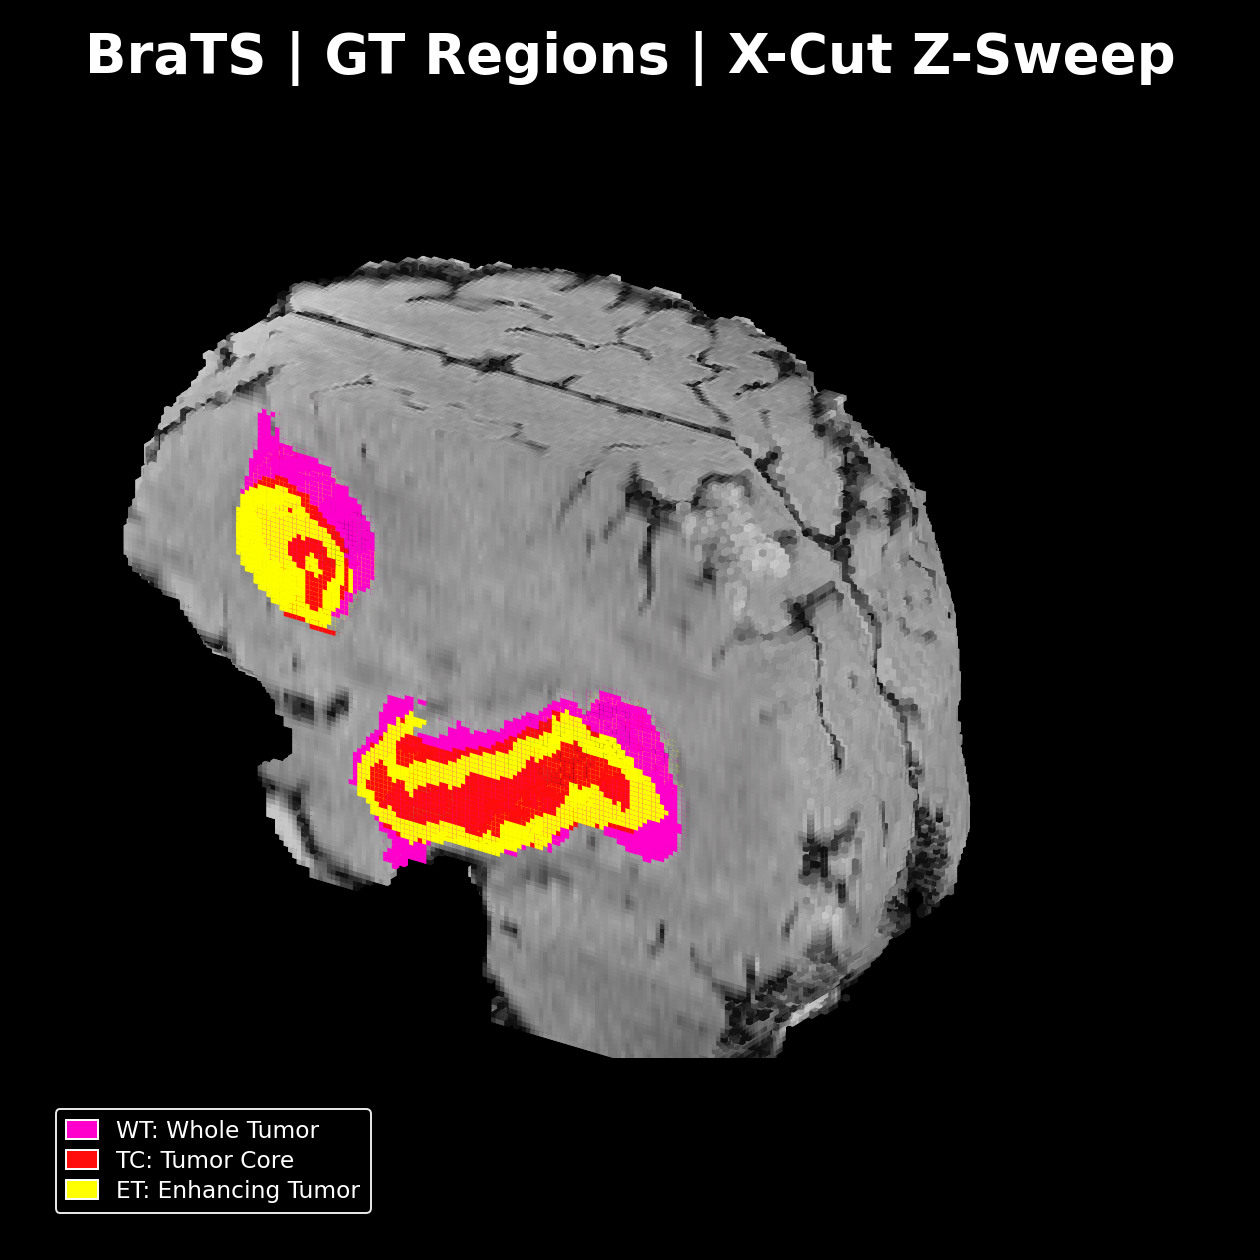

In [5]:
brain_base, seg_base = precompute_xcut_volume(viz_z, flair, seg, X_STOP, Y_STOP)
preview_path = PREVIEW_DIR / f"{PATIENT_ID}_preview_z_{PREVIEW_Z:03d}.png"
save_z_frame(viz_z, brain_base, seg_base, PREVIEW_Z, preview_path, style=STYLE)
display(Image(filename=str(preview_path)))

## Render or resume the full sweep

In [ ]:
if RENDER_VIDEO:
    video_path, frame_paths = render_z_sweep(
        viz_z, flair, seg, frames_dir=FRAMES_DIR, video_dir=VIDEO_DIR,
        patient_id=PATIENT_ID, style=STYLE,
        x_stop=X_STOP, y_stop=Y_STOP, z_step=Z_STEP,
        direction=SWEEP_DIRECTION, fps=FPS, force_render=FORCE_RENDER,
        hold_start_frames=HOLD_START_FRAMES, hold_end_frames=HOLD_END_FRAMES,
    )
    display(Video(str(video_path), embed=True, html_attributes="controls loop"))
else:
    print("Inspect the preview before setting RENDER_VIDEO=True.")

## Rebuild pacing from existing PNGs

This cell changes frame order, holds and duration without rerendering the 3D volume.

In [ ]:
REBUILD_VIDEO = False
REPEAT_EACH_FRAME = 2
REBUILD_HOLD_START = 8
REBUILD_HOLD_END = 8

if REBUILD_VIDEO:
    existing_frames = order_z_frames(FRAMES_DIR, direction=SWEEP_DIRECTION)
    sequence = ([existing_frames[0]] * REBUILD_HOLD_START
                + [path for path in existing_frames for _ in range(REPEAT_EACH_FRAME)]
                + [existing_frames[-1]] * REBUILD_HOLD_END)
    output = VIDEO_DIR / f"{PATIENT_ID}_z_sweep_repeat{REPEAT_EACH_FRAME}_holds.mp4"
    frames_to_mp4(sequence, output, fps=FPS)
    print("Duration (s):", len(sequence) / FPS)
    display(Video(str(output), embed=True, html_attributes="controls loop"))